In [147]:
import pandas as pd
from pandas.plotting import table
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from sklearn.preprocessing import RobustScaler

In [149]:
file_path = "history.xlsx"
df = pd.read_excel(file_path)

In [ ]:
print(df.head())
print(df['action_date'].min())
print(df['action_date'].max())

In [151]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183828 entries, 0 to 183827
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   customer_id             183828 non-null  int64         
 1   product_id              183828 non-null  int64         
 2   action_date             183828 non-null  datetime64[ns]
 3   action_id               183828 non-null  int64         
 4   type                    183828 non-null  object        
 5   age_range               183745 non-null  float64       
 6   gender                  183828 non-null  object        
 7   customer_register_date  183828 non-null  datetime64[ns]
 8   customer_level          183828 non-null  int64         
 9   city_level              183703 non-null  float64       
 10  brand                   183828 non-null  object        
 11  shop_id                 183828 non-null  int64         
 12  category                183828

In [152]:
print(df['type'].value_counts(dropna=False))

type
PageView     163954
Order         10698
Comment        4010
SavedCart      2987
Follow         2179
Name: count, dtype: int64


In [153]:
print(df.isnull().sum())

customer_id                   0
product_id                    0
action_date                   0
action_id                     0
type                          0
age_range                    83
gender                        0
customer_register_date        0
customer_level                0
city_level                  125
brand                         0
shop_id                       0
category                      0
product_market_date           0
vender_id                     0
fans_number                   0
vip_number                    0
shop_register_date        71354
shop_category                 0
shop_score                    0
dtype: int64


In [154]:
#缺失值处理
age_median = int(df['age_range'].median())
df['age_range'] = df['age_range'].fillna(age_median)

city_mode = df['city_level'].mode()[0]  # 计算众数
df['city_level'] = df['city_level'].fillna(city_mode)

df['shop_register_date'] = df['shop_register_date'].fillna('NAH')


In [155]:
print(df.isnull().sum())

customer_id               0
product_id                0
action_date               0
action_id                 0
type                      0
age_range                 0
gender                    0
customer_register_date    0
customer_level            0
city_level                0
brand                     0
shop_id                   0
category                  0
product_market_date       0
vender_id                 0
fans_number               0
vip_number                0
shop_register_date        0
shop_category             0
shop_score                0
dtype: int64


In [156]:
#筛选时间
def filter_by_date(df, start, end):
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    filtered_df = df[(df['action_date'] >= start) & (df['action_date'] < end + pd.Timedelta(days=1))]
    return filtered_df.sort_values('action_date')

start_date = input("请输入开始日期 (格式YYYY-MM-DD): ")
end_date = input("请输入结束日期 (格式YYYY-MM-DD): ")

filtered_df = filter_by_date(df, start_date, end_date)

print(f"\n筛选日期范围: {start_date} 到 {end_date} 的数据如下：")
print(filtered_df)


筛选日期范围: 2024-02-01 到 2024-04-15 的数据如下：
        customer_id  product_id         action_date  action_id      type  \
159227      1158039      148215 2024-02-01 00:00:00    7447336  PageView   
82709       1062027      320893 2024-02-01 00:00:00    5881807  PageView   
117018       150312      138491 2024-02-01 00:01:00    6982364  PageView   
106117       532476      258623 2024-02-01 00:01:00    5161191  PageView   
159228      1158039       17591 2024-02-01 00:02:00    7447336  PageView   
...             ...         ...                 ...        ...       ...   
165394      1475265      268567 2024-04-15 23:57:00    4650987  PageView   
109982       377086      236567 2024-04-15 23:57:00    4863085  PageView   
2482         139171      110400 2024-04-15 23:58:00    2055481  PageView   
63303       1013925      125302 2024-04-15 23:58:00    6321938  PageView   
132169       431341      252566 2024-04-15 23:59:00    1317724  PageView   

        age_range gender customer_register_date

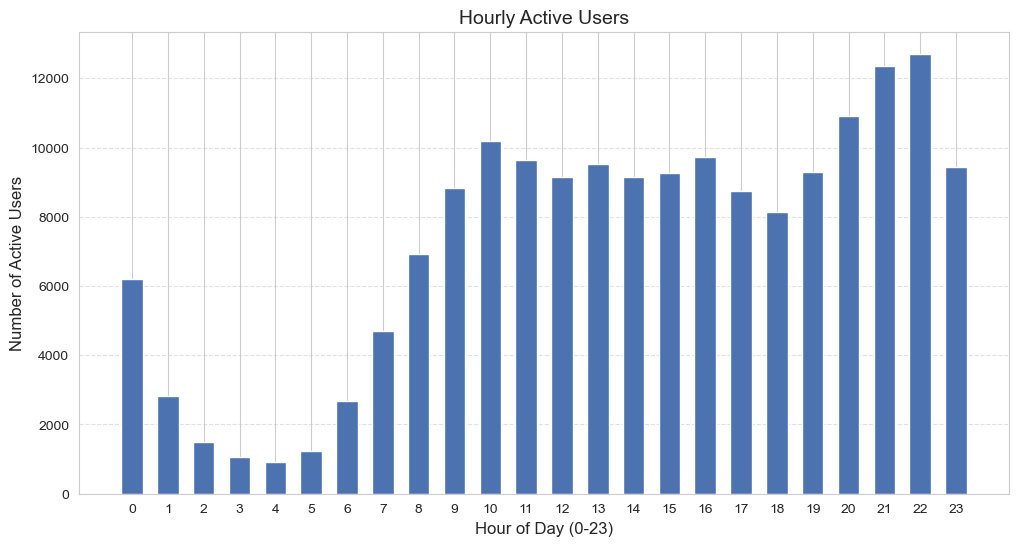

In [159]:
hourly = filtered_df.groupby(filtered_df['action_date'].dt.hour)['customer_id'].nunique()

plt.figure(figsize=(12,6))
plt.bar(hourly.index, hourly.values, width=0.6, color="#4C72B0")
plt.title("Hourly Active Users", fontsize=14)
plt.xlabel("Hour of Day (0-23)", fontsize=12)
plt.ylabel("Number of Active Users", fontsize=12)
plt.xticks(range(0,24))
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [ ]:
#datetime to date
df['action_date'] = pd.to_datetime(df['action_date']).dt.date
print(df['action_date'].head())
print(df['action_date'].min())
print(df['action_date'].max())

In [161]:
#(1)绘制每日行为量分布图
filtered_df['action_date'] = pd.to_datetime(filtered_df['action_date']).dt.date
daily_actions = filtered_df['action_date'].value_counts().sort_index()

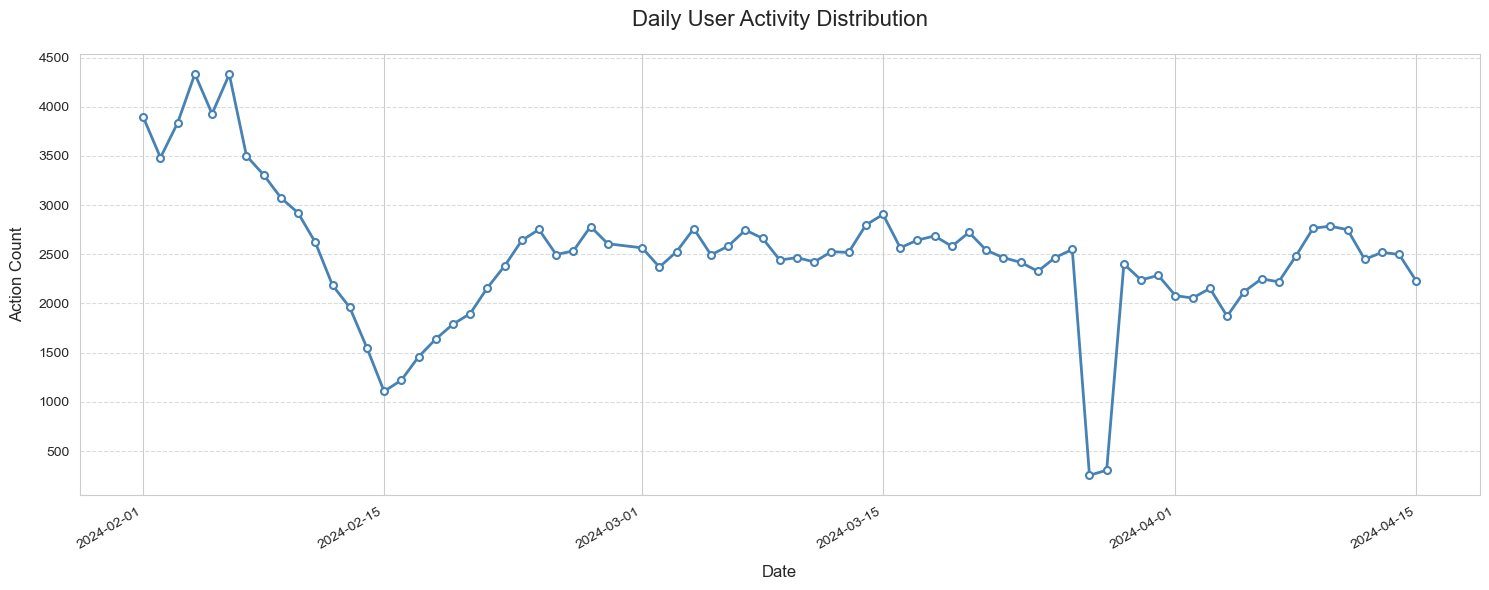

In [162]:
plt.figure(figsize=(15, 6))
plt.plot(
    daily_actions.index,
    daily_actions.values,
    color='steelblue',
    linewidth=2,
    marker='o',
    markersize=5,
    markerfacecolor='white',
    markeredgewidth=1.5
)

# 设置标题和标签
plt.title('Daily User Activity Distribution', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12, labelpad=10)
plt.ylabel('Action Count', fontsize=12, labelpad=10)

# 网格和样式设置
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)

# 自动调整日期显示
plt.gcf().autofmt_xdate()

# 显示图表
plt.tight_layout()
plt.show()

In [163]:
#(2)数据摘要
metrics = {
    "总用户数": filtered_df['customer_id'].nunique(),
    "总商品数": filtered_df['product_id'].nunique(),
    "人均浏览量": round(filtered_df[filtered_df['type']=='PageView'].shape[0] / filtered_df['customer_id'].nunique(), 2),
    "人均下单量": round(filtered_df[filtered_df['type']=='Order'].shape[0] / filtered_df['customer_id'].nunique(), 2),
    "浏览-下单转化率": f"{filtered_df[filtered_df['type']=='Order']['customer_id'].nunique() / filtered_df[filtered_df['type']=='PageView']['customer_id'].nunique() * 100:.2f}%",
    "浏览-加购转化率": f"{filtered_df[filtered_df['type']=='SavedCart']['customer_id'].nunique() / filtered_df[filtered_df['type']=='PageView']['customer_id'].nunique() * 100:.2f}%",
    "商品平均被浏览次数": round(filtered_df[filtered_df['type']=='PageView'].groupby('product_id').size().mean(), 2),
    "商品平均被下单次数": round(filtered_df[filtered_df['type']=='Order'].groupby('product_id').size().mean(), 2)
}

pd.DataFrame.from_dict(metrics, orient='index', columns=['值'])

,值
总用户数,140715
总商品数,52950
人均浏览量,1.17
人均下单量,0.08
浏览-下单转化率,8.56%
浏览-加购率,2.35%
商品平均被浏览次数,3.34
商品平均被下单次数,1.59


In [164]:
#（3）pv/order Top 10 商品统计
top10_product_stats = filtered_df.groupby(['product_id', 'category']).agg(
    views=('type', lambda x: (x == 'PageView').sum()),
    orders=('type', lambda x: (x == 'Order').sum())
).reset_index()

top10_pv = top10_product_stats.sort_values('views', ascending=False).head(10)
top10_order = top10_product_stats.sort_values('orders', ascending=False).head(10)

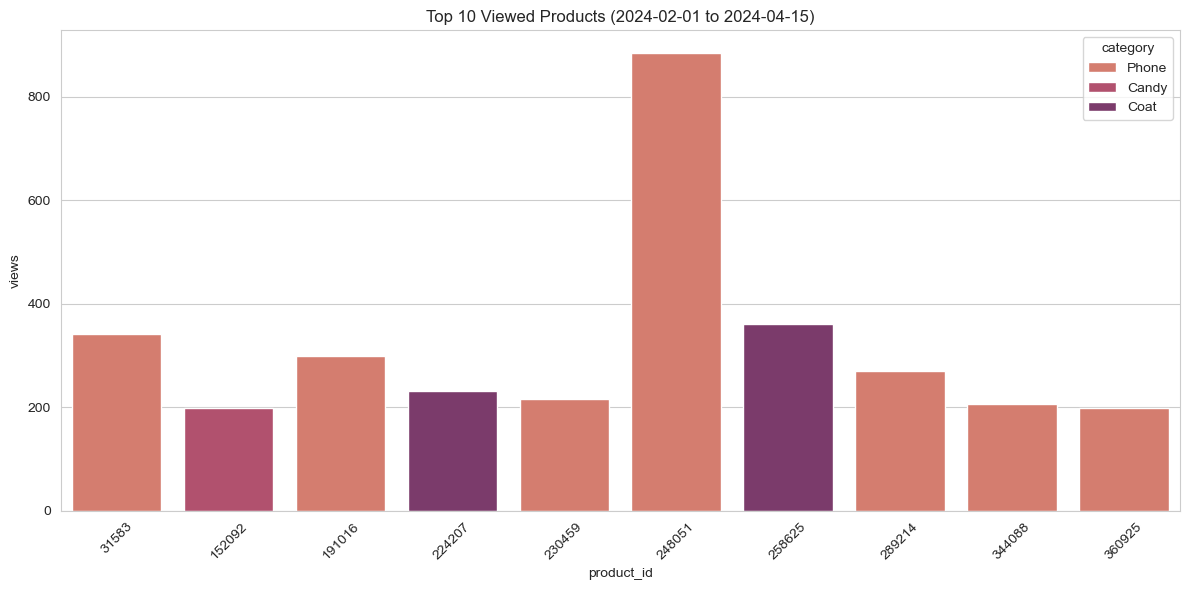

In [165]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Arial'

#top10 浏览商品
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_pv,
    y='views',
    x='product_id',
    hue='category',
    palette='flare',
    dodge=False
)
plt.title(f'Top 10 Viewed Products ({start_date} to {end_date})')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

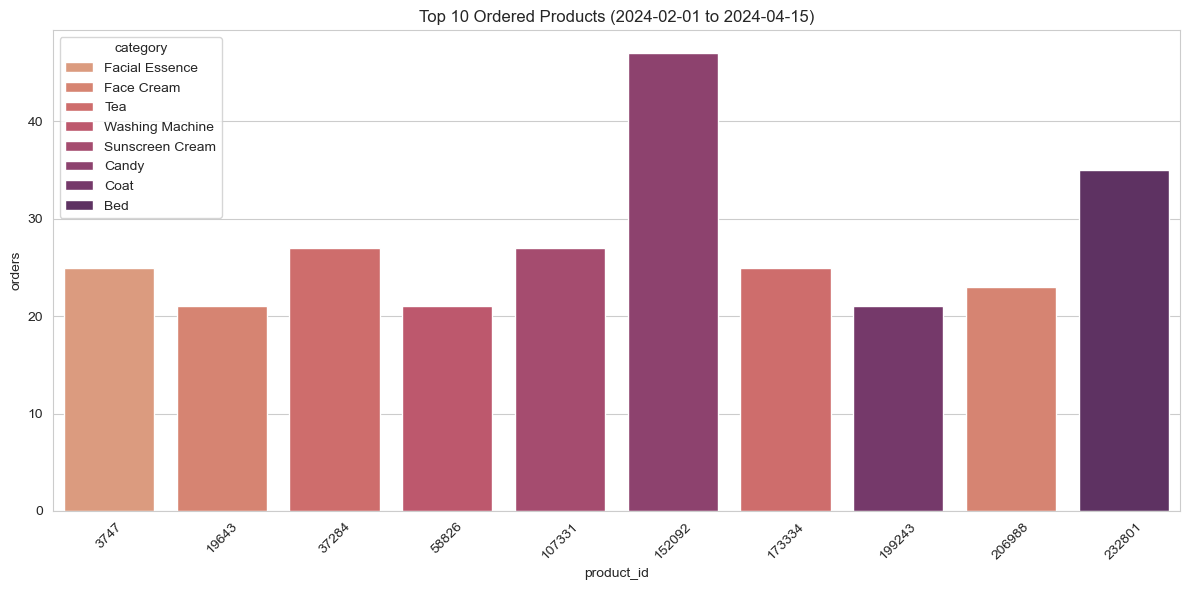

In [166]:
#top10 购买商品
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_order,
    y='orders',  # Fixed: views now on Y-axis
    x='product_id',  # Fixed: product_id now on X-axis
    hue='category',
    palette='flare',
    dodge=False
)
plt.title(f'Top 10 Ordered Products ({start_date} to {end_date})')
plt.xticks(rotation=45)  # Rotate product IDs for readability
plt.tight_layout()
plt.show()


In [167]:
#AAARRR分析漏斗

In [168]:
#Awreness
#---各种行为数统计
behavior_stats = (
    filtered_df.groupby("type")["customer_id"]
    .agg(total_actions="count", unique_users="nunique")
    .reset_index()
)

print("=== 每种行为统计 ===")
print(behavior_stats)

=== 每种行为统计 ===
        type  total_actions  unique_users
0    Comment           4010          3972
1     Follow           2179          2113
2      Order          10698         10652
3   PageView         163954        124433
4  SavedCart           2987          2929


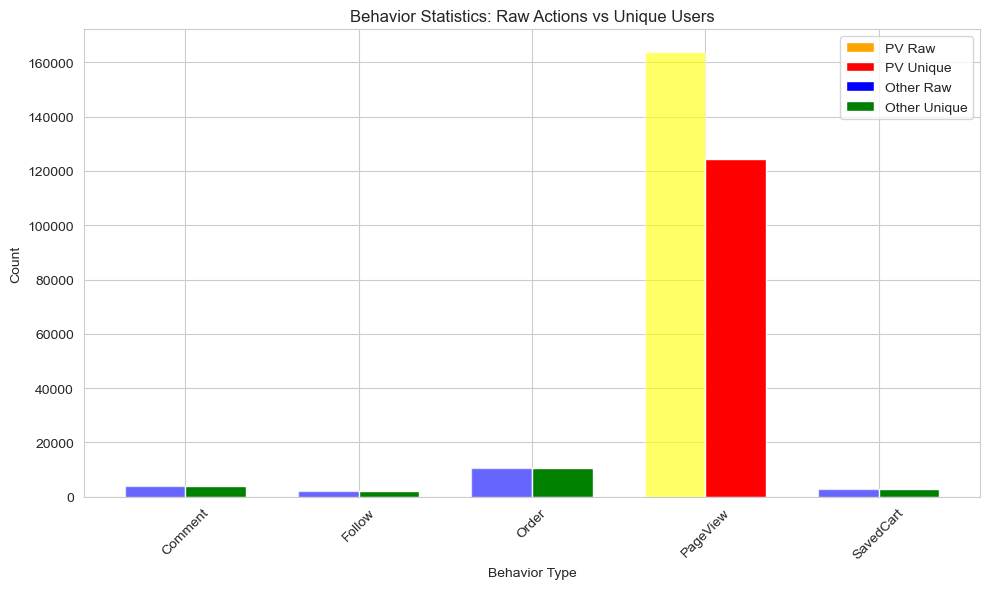

In [169]:
#可视化
x = np.arange(len(behavior_stats))
width = 0.35

colors_raw = []
for t in behavior_stats["type"]:
    if t == "PageView":
        colors_raw.append("yellow")
    else:
        colors_raw.append("blue")

colors_de = []
for t in behavior_stats["type"]:
    if t == "PageView":
        colors_de.append("red")
    else:
        colors_de.append("green")

plt.figure(figsize=(10,6))

plt.bar(x - width/2, behavior_stats["total_actions"], width, color=colors_raw, alpha=0.6)
plt.bar(x + width/2, behavior_stats["unique_users"], width, color=colors_de, alpha=1)

plt.xticks(x, behavior_stats["type"], rotation=45)
plt.xlabel("Behavior Type")
plt.ylabel("Count")
plt.title("Behavior Statistics: Raw Actions vs Unique Users")

legend_elements = [
    Patch(facecolor='orange', label='PV Raw'),
    Patch(facecolor='red', label='PV Unique'),
    Patch(facecolor='blue', label='Other Raw'),
    Patch(facecolor='green', label='Other Unique')
]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()  # 图例必须在 plt.show() 之前设置


In [170]:
#Acquisition
first_actions = (
    filtered_df.groupby(["type", "customer_id"])["action_date"]
    .min()
    .reset_index()
)

acquisition_stats = (
    first_actions.groupby("type")["customer_id"]
    .agg(new_users="nunique")
    .reset_index()
)

In [171]:
awareness_uv = filtered_df["customer_id"].nunique()
acquisition_stats["conversion_rate"] = acquisition_stats["new_users"] / awareness_uv * 100

print("=== Acquisition 统计 ===")
print(acquisition_stats)

=== Acquisition 统计 ===
        type  new_users  conversion_rate
0    Comment       3972         2.822727
1     Follow       2113         1.501617
2      Order      10652         7.569911
3   PageView     124433        88.429094
4  SavedCart       2929         2.081512


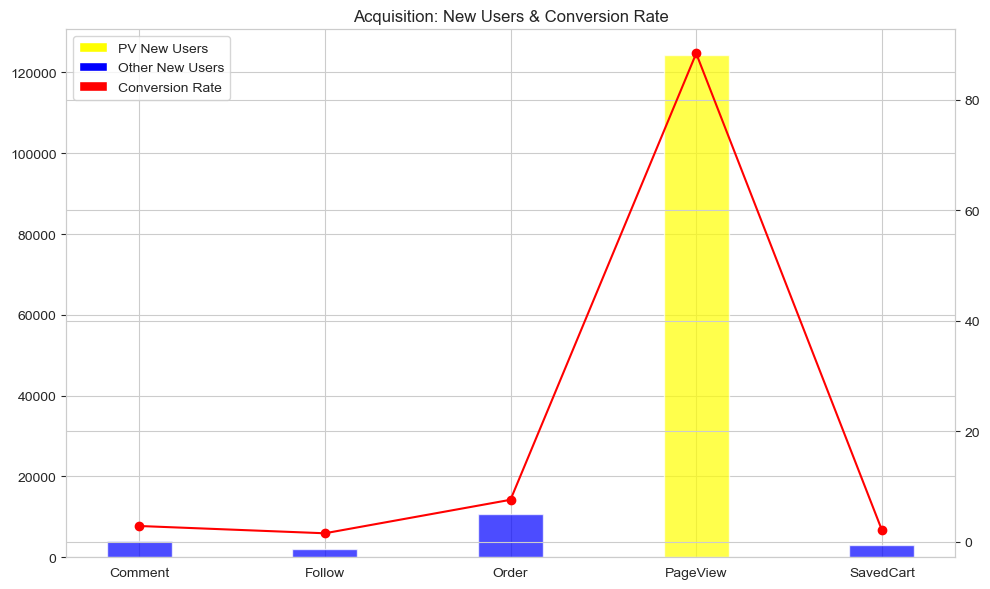

In [172]:
# ===== 可视化 =====
x = np.arange(len(acquisition_stats))
width = 0.35

colors_new = []
for t in acquisition_stats["type"]:
    if t == "PageView":
        colors_new.append("yellow")
    else:
        colors_new.append("blue")

plt.figure(figsize=(10, 6))

# 新增用户柱状图
plt.bar(x, acquisition_stats["new_users"], width, color=colors_new, alpha=0.7, label="New Users")

plt.twinx()
plt.plot(x, acquisition_stats["conversion_rate"], color='red', marker='o', label="Conversion Rate (%)")

plt.xticks(x, acquisition_stats["type"], rotation=45)
plt.xlabel("Behavior Type")
plt.title("Acquisition: New Users & Conversion Rate")

legend_elements = [
    Patch(facecolor='yellow', label='PV New Users'),
    Patch(facecolor='blue', label='Other New Users'),
    Patch(facecolor='red', label='Conversion Rate')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

In [173]:
#---日新增用户趋势图
first_actions_daily = (
    filtered_df.groupby(["type", "customer_id"])["action_date"]
    .min()
    .reset_index()
)

daily_new_users = (
    first_actions_daily.groupby(["action_date", "type"])["customer_id"]
    .nunique()
    .reset_index()
    .sort_values("action_date")
)

total_daily_new_users = (
    first_actions_daily.groupby("action_date")["customer_id"]
    .nunique()
    .reset_index()
)

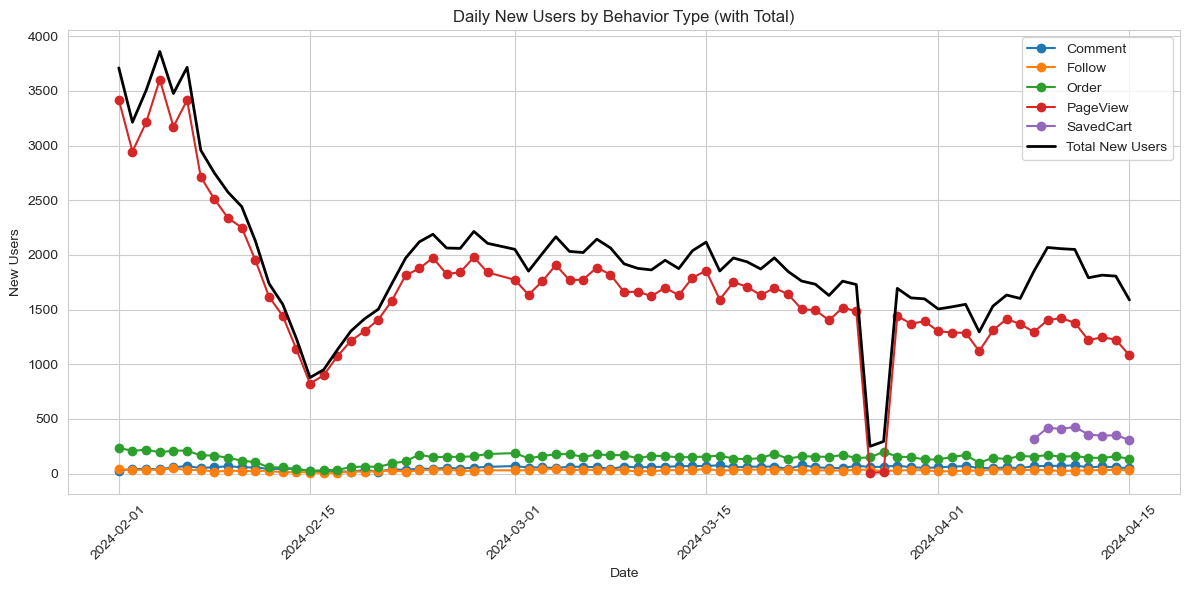

In [174]:
plt.figure(figsize=(12, 6))

# 各行为折线
for b in daily_new_users["type"].unique():
    subset = daily_new_users[daily_new_users["type"] == b]
    plt.plot(subset["action_date"], subset["customer_id"], marker='o', label=b)

# 总新增用户实线
plt.plot(total_daily_new_users["action_date"], total_daily_new_users["customer_id"],
         color='black', linestyle='-', linewidth=2, label="Total New Users")

plt.xlabel("Date")
plt.ylabel("New Users")
plt.title("Daily New Users by Behavior Type (with Total)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [175]:
# 每个用户的首次行为（整个数据）



In [176]:
# 每个用户首次行为
first_action_users = (
    filtered_df.groupby("customer_id")["action_date"]
    .min()
    .reset_index()
)

first_action_df = pd.merge(
    first_action_users,
    filtered_df[["customer_id", "city_level", "shop_category", "product_id"]],
    on="customer_id",
    how="left"
).drop_duplicates(subset=["customer_id"])

In [177]:
# ----统计 Top10 新增用户函数
def top10_new_users(df, group_col):
    temp = df.groupby(group_col)["customer_id"].count().reset_index()
    temp.columns = [group_col, "new_users"]
    return temp.sort_values("new_users", ascending=False).head(10)

new_users_by_city = top10_new_users(first_action_df, "city_level")
new_users_by_shop = top10_new_users(first_action_df, "shop_category")
new_users_by_product = top10_new_users(first_action_df, "product_id")

In [178]:
def plot_single_color_table(df, index_col, value_col, title, title_color="skyblue", cell_color="#2E86C1"):
    plt.figure(figsize=(6, 4))

    n = len(df)
    colors = [[cell_color, cell_color] for _ in range(n)]  # 内容浅色
    plt.table(cellText=df[[index_col, value_col]].values,
              colLabels=[index_col, value_col],
              cellColours=colors,
              colColours=[title_color, title_color],  # 标题深色
              cellLoc="center",
              loc="center")

    plt.axis("off")
    plt.title(title, fontsize=14, pad=10)
    plt.show()

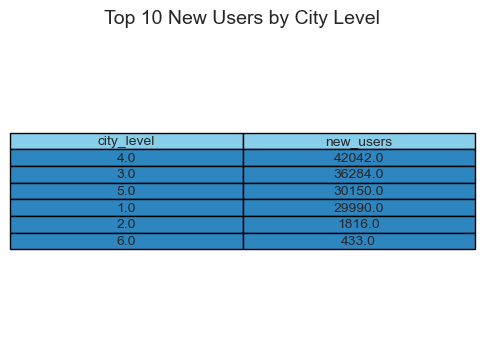

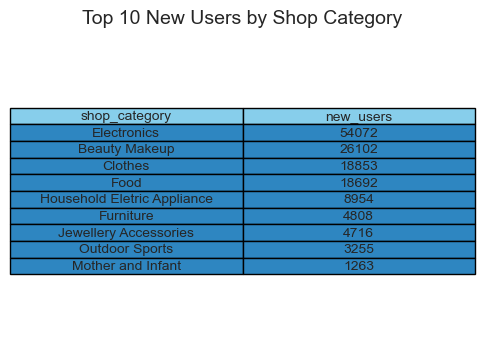

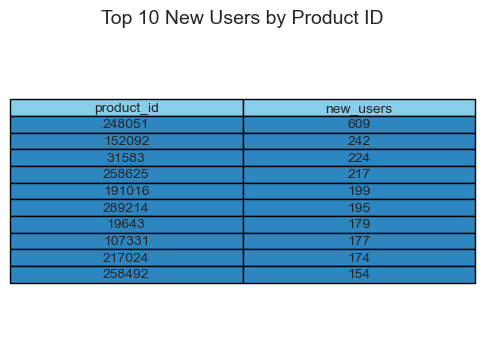

In [179]:
# 绘制表格
plot_single_color_table(new_users_by_city, "city_level", "new_users", "Top 10 New Users by City Level")
plot_single_color_table(new_users_by_shop, "shop_category", "new_users", "Top 10 New Users by Shop Category")
plot_single_color_table(new_users_by_product, "product_id", "new_users", "Top 10 New Users by Product ID")

In [224]:
#Activation
# 1. 定义激活行为
activation_behaviors = ["Order", "SavedCart", "Follow"]

# 2. 每个用户首次行为日期
first_action_date = filtered_df.groupby("customer_id")["action_date"].min().reset_index()
first_action_date.columns = ["customer_id", "first_action_date"]

activation_df = pd.merge(filtered_df, first_action_date, on="customer_id", how="left")


In [ ]:
activation_df = activation_df[
    (activation_df["type"].isin(activation_behaviors)) &
    (activation_df["action_date"] >= activation_df["first_action_date"])
]

activated_users = activation_df.groupby("customer_id")["type"].first().reset_index()
activated_users["activated"] = 1

activation_users = pd.merge(first_action_date, activated_users[["customer_id", "activated"]],
                            on="customer_id", how="left")
activation_users["activated"] = activation_users["activated"].fillna(0)

total_users = activation_users.shape[0]
activated_count = activation_users["activated"].sum()
activation_rate = activated_count / total_users * 100

print(f"Total users: {total_users}")
print(f"Activated users: {activated_count}")
print(f"Activation rate: {activation_rate:.2f}%")

In [213]:
daily_activation = (
    activation_users.groupby("first_action_date")["activated"]
    .agg(activated_users="sum", new_users="count")
    .reset_index()
)
daily_activation["activation_rate"] = daily_activation["activated_users"] / daily_activation["new_users"] * 100

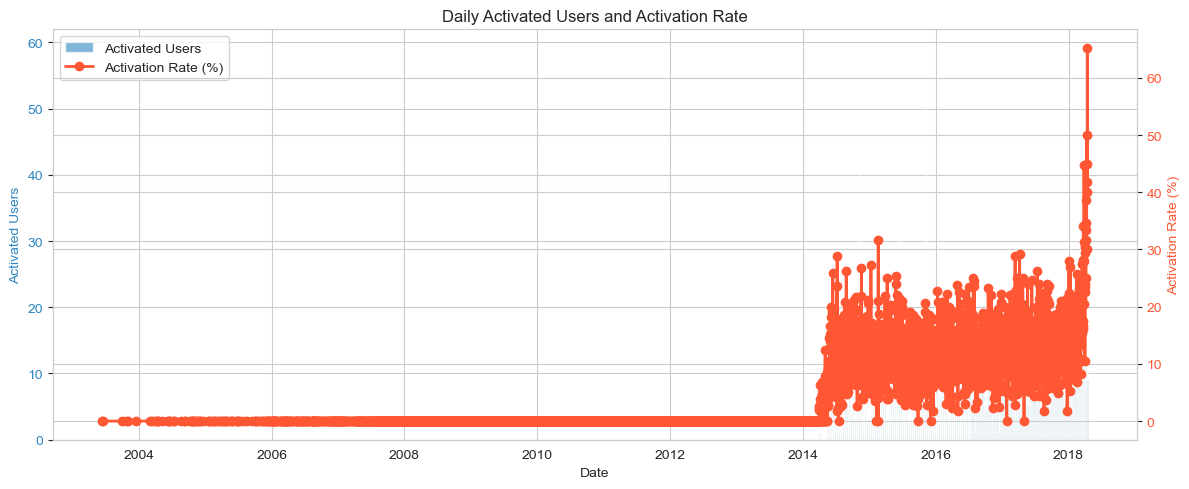

In [216]:
fig, ax1 = plt.subplots(figsize=(12,5))

# 蓝色柱状图：每日激活用户
ax1.bar(daily_activation["first_action_date"], daily_activation["activated_users"],
        color="#2E86C1", alpha=0.6, label="Activated Users")
ax1.set_xlabel("Date")
ax1.set_ylabel("Activated Users", color="#2E86C1")
ax1.tick_params(axis='y', labelcolor="#2E86C1")

# 右轴折线：激活率
ax2 = ax1.twinx()
ax2.plot(daily_activation["first_action_date"], daily_activation["activation_rate"],
         color="#FF5733", linewidth=2, marker='o', label="Activation Rate (%)")
ax2.set_ylabel("Activation Rate (%)", color="#FF5733")
ax2.tick_params(axis='y', labelcolor="#FF5733")

# 图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.title("Daily Activated Users and Activation Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [184]:
#Retention
first_action = filtered_df.groupby('customer_id')['action_date'].min().reset_index()
first_action.columns = ['customer_id', 'first_action_date']

# 2. 合并回原数据
filtered_df = filtered_df.merge(first_action, on='customer_id', how='left', suffixes=('', '_first'))

In [185]:
# 计算距首次行为天数
filtered_df['days_since_first'] = filtered_df.apply(
    lambda row: (row['action_date'] - row['first_action_date']).days, axis=1
)

# 4. 3天分箱
filtered_df['retention_bin'] = filtered_df['days_since_first'].apply(lambda x: (x // 3) * 3)

# 5. cohort 活跃用户数
retention_count = filtered_df.groupby(['first_action_date', 'retention_bin'])['customer_id']\
    .nunique().unstack(fill_value=0)

# 6. cohort 总用户数
cohort_size = filtered_df.groupby('first_action_date')['customer_id'].nunique()

# 7. 留存率
retention_rate = retention_count.divide(cohort_size, axis=0)

# 8. 转换为百分比
retention_rate_pct = retention_rate * 100

In [186]:
retention_rate_pct.columns = retention_rate_pct.columns.map(
    lambda x: (retention_rate_pct.index[0] + pd.Timedelta(days=int(x))).strftime('%Y-%m-%d')
)

# 10. index 转字符串显示
retention_rate_pct.index = retention_rate_pct.index.map(lambda x: x.strftime('%Y-%m-%d'))

In [187]:
def style_table(df):
    styled_df = df.style\
        .format("{:.1f}%")\
        .background_gradient(cmap='Blues', axis=None)\
        .set_caption("3-Day Binned Retention Rate Table (%)")\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#1f4e79'),
                                         ('color', 'white'),
                                         ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'center')]}
        ])\
        .applymap(lambda x: 'color: red' if x == 0 else '')
    return styled_df

# 12. 输出表格
styled_retention = style_table(retention_rate_pct)
styled_retention

/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_6792/3899817961.py:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'color: red' if x == 0 else '')


retention_bin,2024-02-01,2024-02-04,2024-02-07,2024-02-10,2024-02-13,2024-02-16,2024-02-19,2024-02-22,2024-02-25,2024-02-28,2024-03-02,2024-03-05,2024-03-08,2024-03-11,2024-03-14,2024-03-17,2024-03-20,2024-03-23,2024-03-26,2024-03-29,2024-04-01,2024-04-04,2024-04-07,2024-04-10,2024-04-13
first_action_date,,,,,,,,,,,,,,,,,,,,,,,,,
2024-02-01,100.0%,6.2%,4.9%,3.4%,2.4%,1.7%,2.2%,2.3%,2.5%,2.0%,2.6%,2.2%,2.4%,2.5%,3.2%,3.0%,2.6%,2.8%,1.3%,2.5%,2.2%,2.1%,2.2%,2.7%,2.2%
2024-02-02,100.0%,5.2%,3.5%,2.9%,1.4%,2.2%,1.8%,2.4%,1.9%,1.6%,2.0%,2.2%,1.8%,2.4%,2.2%,2.4%,2.1%,1.7%,0.7%,1.9%,1.6%,1.4%,1.9%,2.0%,1.4%
2024-02-03,100.0%,4.9%,4.1%,2.6%,1.7%,1.6%,2.0%,1.5%,1.5%,1.7%,1.7%,1.8%,2.1%,2.3%,2.1%,1.7%,2.1%,1.8%,1.5%,1.5%,1.3%,1.5%,1.8%,1.7%,0.7%
2024-02-04,100.0%,4.3%,3.1%,1.9%,1.6%,2.0%,2.2%,1.8%,1.3%,1.7%,1.9%,1.7%,1.7%,2.2%,2.0%,1.7%,1.5%,0.7%,1.8%,1.5%,1.5%,1.3%,1.7%,1.6%,0.0%
2024-02-05,100.0%,3.6%,2.4%,1.3%,1.2%,1.6%,1.9%,1.9%,1.2%,1.5%,1.6%,1.6%,1.9%,1.6%,1.8%,1.8%,1.7%,0.6%,1.4%,1.2%,1.0%,1.4%,1.6%,0.9%,0.0%
2024-02-06,100.0%,3.3%,2.2%,1.4%,2.1%,1.8%,1.9%,1.5%,1.9%,1.5%,2.0%,2.3%,1.7%,1.9%,2.1%,1.9%,1.3%,1.1%,1.0%,1.2%,1.2%,1.5%,1.6%,0.6%,0.0%
2024-02-07,100.0%,3.8%,2.1%,1.6%,2.0%,2.0%,2.0%,1.2%,2.0%,1.9%,1.8%,1.7%,2.3%,1.9%,2.0%,1.5%,0.9%,2.1%,1.3%,1.3%,1.5%,1.7%,1.5%,0.0%,0.0%
2024-02-08,100.0%,3.6%,1.6%,1.8%,1.8%,1.9%,2.0%,1.1%,1.5%,1.8%,1.9%,1.7%,1.8%,1.7%,1.6%,1.9%,0.3%,1.4%,1.3%,1.1%,1.7%,1.2%,0.7%,0.0%,0.0%
2024-02-09,100.0%,3.0%,1.5%,1.6%,1.6%,2.0%,1.2%,1.7%,1.2%,1.5%,1.4%,1.2%,1.2%,1.4%,1.1%,1.2%,0.7%,1.1%,1.4%,1.1%,1.3%,1.2%,0.4%,0.0%,0.0%


In [ ]:
#复购率-人数分布图

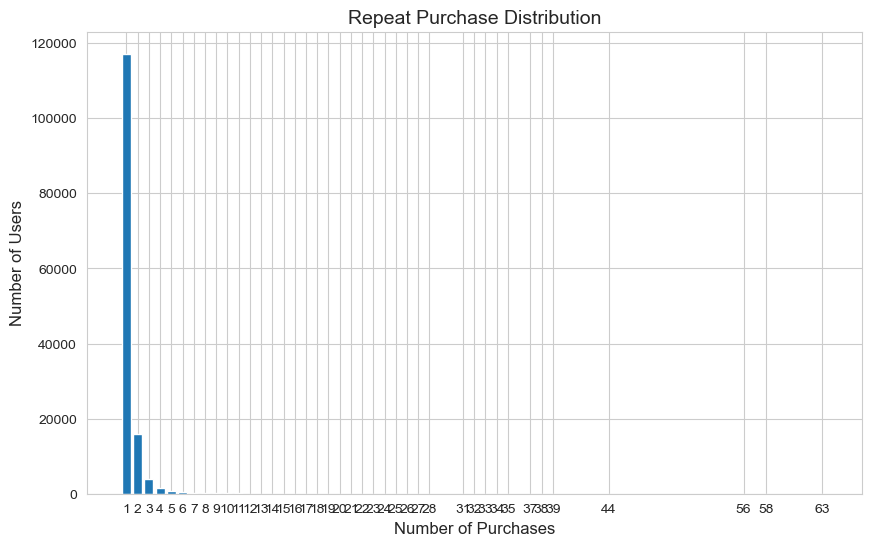

In [195]:
order_counts = filtered_df.groupby("customer_id")["product_id"].count()

# 统计不同购买次数对应的人数
repeat_distribution = order_counts.value_counts().sort_index()

# 绘制柱状图
plt.figure(figsize=(10,6))
plt.bar(repeat_distribution.index, repeat_distribution.values)

plt.title("Repeat Purchase Distribution", fontsize=14)
plt.xlabel("Number of Purchases", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.xticks(repeat_distribution.index)
plt.show()


In [188]:
#RF score

In [189]:
snapshot_date = filtered_df['action_date'].max() + pd.Timedelta(days=1)

# 统计每个用户的 Recency 和 Frequency
rf_table = filtered_df.groupby('customer_id').agg(
    recency=('action_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('action_date', 'count')
).reset_index()

In [191]:
rf_table['R_score'] = pd.cut(rf_table['recency'],
                             bins=[-1,7,14,30,60,rf_table['recency'].max()],
                             labels=[5,4,3,2,1]).astype(int)

rf_table['F_score'] = pd.cut(rf_table['frequency'],
                             bins=[-1,1,2,5,10,rf_table['frequency'].max()],
                             labels=[1,2,3,4,5]).astype(int)

rf_table['RF_score'] = rf_table['R_score'] + rf_table['F_score']

rf_table_display = rf_table[['customer_id','R_score','F_score','RF_score']].copy()
rf_table_display.head(10)


,customer_id,R_score,F_score,RF_score
0,17,2,1,3
1,22,2,1,3
2,24,2,1,3
3,29,2,1,3
4,38,3,1,4
5,45,2,2,4
6,60,2,1,3
7,62,1,1,2
8,64,5,1,6
9,83,1,1,2


In [192]:
def categorize_user(rf_score):
    if rf_score >= 8:
        return "High Value"
    elif rf_score >= 5:
        return "Medium Value"
    else:
        return "Low Value"

rf_table['value_segment'] = rf_table['RF_score'].apply(categorize_user)

# 查看各组人数
rf_table['value_segment'].value_counts()

value_segment
Low Value       104383
Medium Value     33853
High Value        2479
Name: count, dtype: int64